# AIFM Real Estate — Risk Notebook

Risk limits are defined in the fund's offering document and monitored against
internal thresholds. No regulatory VaR limit applies (unlike UCITS).

Key regulatory obligations under AIFMD:
- **Leverage**: gross and commitment method (Annex IV)
- **Stress testing**: market, liquidity, and counterparty scenarios (Annex VI)
- **Liquidity risk**: portfolio liquidity profile and redemption stress
- **Annex IV reporting**: quarterly to CSSF. AIFMD II (Directive 2024/927/EU)
  expanded requirements, adding granular data on liquidity management tools,
  loan origination, and delegation arrangements.

Regulatory framework:
- AIFMD: Directive 2011/61/EU
- AIFMD II: Directive 2024/927/EU
- Delegated Regulation: EU 231/2013
- Annex IV reporting: EU 231/2013, ESMA technical guidance v1.7 (July 2024)
- Annex VI stress testing: ESMA/2020/1498
- Luxembourg implementation: Law of 12 July 2013 on AIFMs (AIFM Law)

Dual UCITS/AIFM ManCo:
- CSSF Regulation 10-04 (organisational and prudential requirements)
- CSSF Regulation 22-05 (sustainability requirements, amending 10-04)

#### In this notebook

**AIFM Private RealEstate. Strategy: direct property investments (office, logistics,
retail, residential) across core European markets, complemented by listed REITs
for liquidity management. EUR and FX-hedged exposures.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.plot_style import ACCENT, ACCENT2, ACCENT3
import warnings
warnings.filterwarnings('ignore')

from src.setup_db import run as setup_db
setup_db()

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.leverage_config import INSTRUMENT_SOURCE
from src.risk_utils import (
    var_historical, var_parametric, var_scale, var_montecarlo,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    stress_property, stress_rental, stress_ltv,
    days_to_liquidate, liquidity_buckets, redemption_stress,
)

FUND_ID    = 'AIFM_RealEstate'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

CONFIDENCE = 0.99
HORIZON    = 20

Database exists.
Positions already loaded (88,000 rows). Skipping.
positions_enriched exists. Skipping enrichment.

Database ready.
MockBloomberg: connected (simulation mode)
Swap import to RealBloomberg for production use.


## 1. Load and Validate Positions

Positions are queried from SQLite, loaded daily from the fund administrator
Excel export. The flow is:

```
Fund admin Excel → load_positions() → SQLite → query_positions() → notebook
```

The Real Estate fund holds two types of assets with fundamentally different
data sources and risk characteristics:

- **Direct properties**: quarterly appraisal valuation, no Bloomberg ticker,
  fund admin data only (LTV, rental yield, vacancy rate, property type)
- **Listed REITs**: daily market prices, Bloomberg enrichment (beta, ADV)

`get_risk_ready_df` routes each position to the correct enrichment source
automatically based on the `is_direct_property` flag.


In [2]:
positions = query_positions(ENGINE, FUND_ID, TODAY)
risk_df   = get_risk_ready_df(ENGINE, FUND_ID, TODAY)
NAV       = risk_df['market_value_eur'].sum()

direct    = risk_df[risk_df['is_direct_property'] == True]
listed    = risk_df[risk_df['is_direct_property'] == False]

print(f"Fund              : {FUND_ID}")
print(f"Valuation date    : {TODAY}")
print(f"Total positions   : {len(positions)}")
print(f"Direct properties : {len(direct)}")
print(f"Listed REITs/FX   : {len(listed)}")
print(f"NAV (EUR)         : {NAV:,.0f}")
print(f"Direct prop (EUR) : {direct['market_value_eur'].sum():,.0f}")
print(f"Listed (EUR)      : {listed['market_value_eur'].sum():,.0f}")

Fund              : AIFM_RealEstate
Valuation date    : 2026-05-13
Total positions   : 8
Direct properties : 4
Listed REITs/FX   : 4
NAV (EUR)         : 168,874,400
Direct prop (EUR) : 127,000,000
Listed (EUR)      : 41,874,400


In [3]:
# Asset class breakdown
breakdown = risk_df.groupby('asset_class').agg(
    market_value_eur=('market_value_eur', 'sum'),
    n_positions=('isin', 'count'),
).sort_values('market_value_eur', ascending=False)

breakdown['weight_pct'] = breakdown['market_value_eur'] / NAV * 100

print(f"{'Asset Class':<20} {'MV (EUR)':>15} {'Weight':>8} {'# Pos':>6}")
print('-' * 52)
for ac, row in breakdown.iterrows():
    print(f"{ac:<20} {row['market_value_eur']:>15,.0f} {row['weight_pct']:>7.1f}% {row['n_positions']:>6}")
print('-' * 52)
print(f"{'NAV':<20} {NAV:>15,.0f} {'100.0%':>8}")

Asset Class                 MV (EUR)   Weight  # Pos
----------------------------------------------------
Real Estate              149,423,400    88.5%    6.0
Cash                      15,000,000     8.9%    1.0
FX                         4,451,000     2.6%    1.0
----------------------------------------------------
NAV                      168,874,400   100.0%


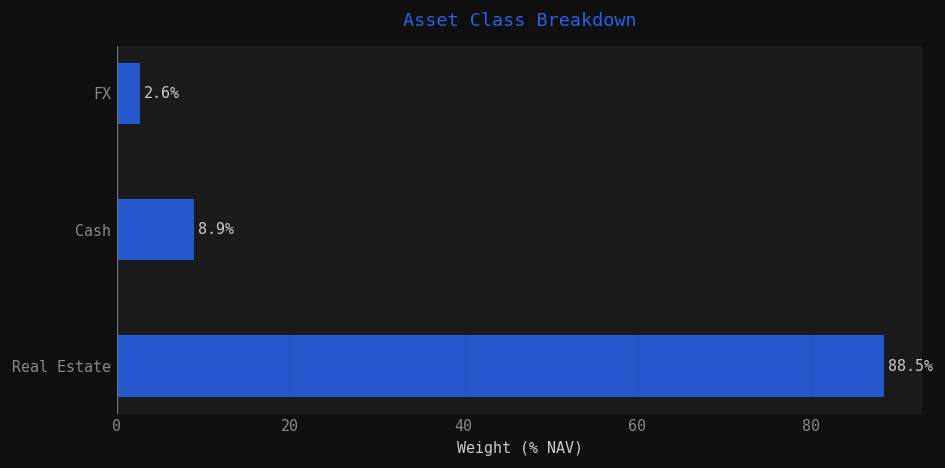

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT2 if v < 0 else ACCENT for v in breakdown['weight_pct']]
bars = ax.barh(breakdown.index, breakdown['weight_pct'],
               color=colors, height=0.45, alpha=0.85)
ax.axvline(0, color='#6b7280', lw=0.8)
ax.set_xlabel('Weight (% NAV)', fontsize=9)
ax.set_title('Asset Class Breakdown', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='x', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, breakdown['weight_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. VaR and Expected Shortfall

Direct properties are valued quarterly by independent appraisers. The absence of
daily pricing makes historical simulation VaR inapplicable to this portion of the
portfolio. AIFMD does not mandate VaR for real estate AIFs; regulatory risk
monitoring focuses on leverage, liquidity mismatch, and stress testing.

VaR is computed as follows:
- **Listed REITs**: historical simulation on daily NAV returns
- **Direct properties**: parametric VaR using an assumed annual volatility
  calibrated to MSCI Real Estate index data, disclosed in the RMP as an approximation
- **Combined**: liquid and illiquid VaR aggregated assuming independence

## 3. Direct Property Analysis

Key metrics for direct property positions: LTV, rental yield, and vacancy rate.
Sourced from the fund administrator quarterly valuation report.

- **LTV**: debt as % of property value. Covenant typically at 60-65%.
- **Rental yield**: annual rent / property value. Gross, before vacancy.
- **Vacancy rate**: % of lettable space not generating income.
- **Effective yield**: rental yield × (1 − vacancy rate). Actual income yield.

In [5]:
prop_df = direct[direct['asset_class'] == 'Real Estate'].copy()
prop_df['effective_yield'] = prop_df['rental_yield_pct'] * (1 - prop_df['vacancy_rate_pct'] / 100)

summary = prop_df[[
    'instrument_name', 'country', 'market_value_eur',
    'ltv_pct', 'rental_yield_pct', 'vacancy_rate_pct',
    'effective_yield', 'property_type', 'valuation_date'
]].copy()

summary['weight_pct'] = summary['market_value_eur'] / NAV * 100

print(f"{'Property':<35} {'MV (EUR)':>12} {'Wgt':>6} {'LTV':>6} {'Yield':>7} {'Vacancy':>8} {'Eff.Yield':>10}")
print('-' * 92)
for _, row in summary.iterrows():
    print(f"{row['instrument_name']:<35} {row['market_value_eur']:>12,.0f} "
          f"{row['weight_pct']:>5.1f}% {row['ltv_pct']:>5.1f}% "
          f"{row['rental_yield_pct']:>6.1f}% {row['vacancy_rate_pct']:>7.1f}% "
          f"{row['effective_yield']:>9.1f}%")
print('-' * 92)

wav_ltv    = (summary['ltv_pct'] * summary['market_value_eur']).sum() / summary['market_value_eur'].sum()
wav_yield  = (summary['rental_yield_pct'] * summary['market_value_eur']).sum() / summary['market_value_eur'].sum()
wav_vac    = (summary['vacancy_rate_pct'] * summary['market_value_eur']).sum() / summary['market_value_eur'].sum()
wav_eff    = (summary['effective_yield'] * summary['market_value_eur']).sum() / summary['market_value_eur'].sum()
print(f"{'Weighted average':<35} {summary['market_value_eur'].sum():>12,.0f} "
      f"{'':>6} {wav_ltv:>5.1f}% {wav_yield:>6.1f}% {wav_vac:>7.1f}% {wav_eff:>9.1f}%")

Property                                MV (EUR)    Wgt    LTV   Yield  Vacancy  Eff.Yield
--------------------------------------------------------------------------------------------
Office Tower Luxembourg City          45,000,000  26.6%  42.5%    4.2%     8.5%       3.8%
Logistics Park Frankfurt              32,000,000  18.9%  38.2%    5.1%     2.0%       5.0%
Retail Centre Paris                   28,000,000  16.6%  55.0%    3.8%    15.0%       3.2%
Residential Complex Amsterdam         22,000,000  13.0%  48.0%    3.2%     3.5%       3.1%
--------------------------------------------------------------------------------------------
Weighted average                     127,000,000         45.1%    4.2%     7.4%       3.9%


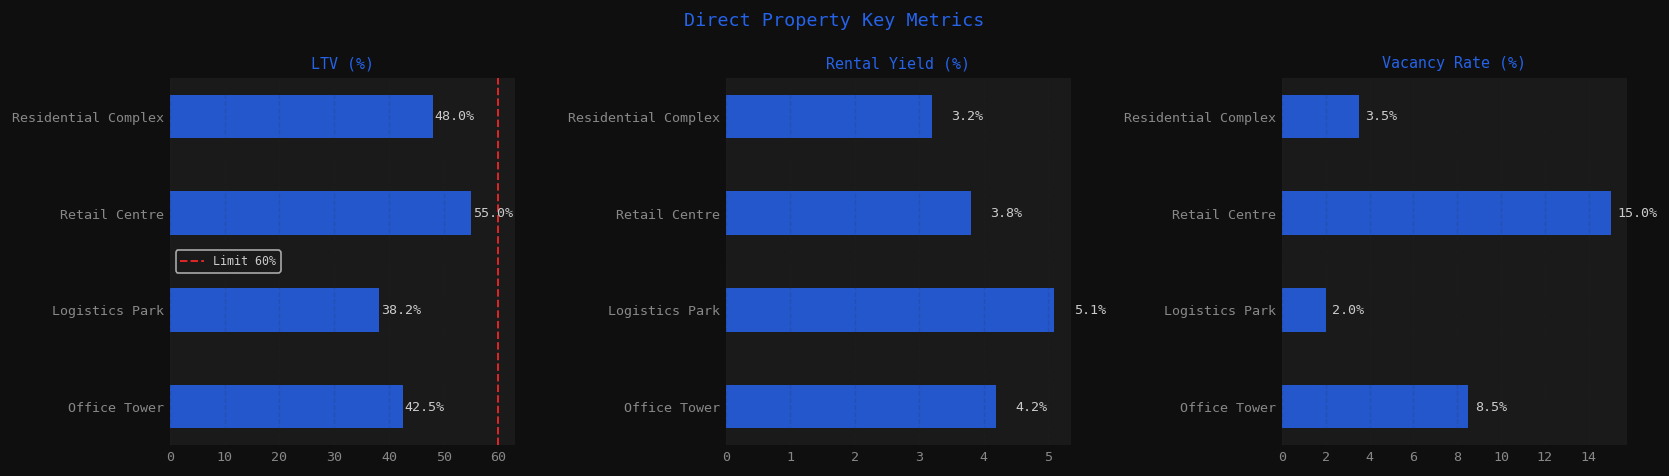

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Direct Property Key Metrics', color=ACCENT, fontsize=11)

names = [n.split(' ')[0] + ' ' + n.split(' ')[1] for n in summary['instrument_name']]

for ax, col, title, limit in zip(
    axes,
    ['ltv_pct', 'rental_yield_pct', 'vacancy_rate_pct'],
    ['LTV (%)', 'Rental Yield (%)', 'Vacancy Rate (%)'],
    [60, None, None]
):
    colors = [ACCENT2 if (limit and v > limit) else ACCENT
              for v in summary[col]]
    bars = ax.barh(names, summary[col], color=colors,
                   height=0.45, alpha=0.85)
    if limit:
        ax.axvline(limit, color=ACCENT2, lw=1.2,
                   linestyle='--', label=f'Limit {limit}%')
        ax.legend(fontsize=7)
    ax.set_title(title, fontsize=9, color=ACCENT)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.grid(True, axis='x', alpha=0.15, linestyle='--')
    ax.tick_params(labelsize=8, length=0)
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Leverage (Annex IV)

AIFMD requires leverage to be reported using two methods:

- **Gross method**: sum of absolute exposures divided by NAV. No netting allowed.
  Derivatives converted to equivalent underlying exposure.
- **Commitment method**: hedging and netting arrangements are recognised.
  Offsetting positions in the same underlying reduce exposure.

Limits are set in the fund's offering document and reported quarterly to the CSSF
in Annex IV. AIFMD II (Directive 2024/927/EU) expanded reporting requirements,
including the breakdown by:
* asset class
* instrument type
* source: financial borrowing, synthetic leverage through derivatives, and repo/reverse repo.

The expanded disclosure makes it easier for regulators to identify funds building leverage through
derivatives rather than borrowing.

In [7]:
# MRS-23: Leverage computation - Gross and Commitment method

# ----------------------------------------------------------------
# Gross method: sum of absolute exposures / NAV
# ----------------------------------------------------------------
risk_df['abs_exposure'] = risk_df['market_value_eur'].abs()

deriv_rows     = risk_df[risk_df['asset_class'] == 'Derivative'].copy()
deriv_notional = 0.0
for _, row in deriv_rows.iterrows():
    ticker        = 'SPXW 260619P05500 Index'
    bbg_data      = BBG.bdp(ticker, ['DELTA', 'OPT_UNDL_PX', 'CONTRACT_SIZE'])
    delta         = abs(bbg_data.loc[ticker, 'DELTA'])
    undl_px       = bbg_data.loc[ticker, 'OPT_UNDL_PX']
    contract_size = bbg_data.loc[ticker, 'CONTRACT_SIZE']
    quantity      = abs(row['quantity'])
    fx_rate       = 0.89
    deriv_notional += delta * quantity * contract_size * undl_px * fx_rate

risk_df['gross_exposure'] = risk_df.apply(
    lambda r: deriv_notional if r['asset_class'] == 'Derivative'
    else (0.0 if r['asset_class'] == 'Cash'
    else r['abs_exposure']),
    axis=1
)

gross_leverage = risk_df['gross_exposure'].sum() / NAV

# ----------------------------------------------------------------
# Commitment method
# ----------------------------------------------------------------
hedge_mv            = risk_df[risk_df['is_hedge'] == True]['market_value_eur'].sum()
all_mv              = risk_df[risk_df['asset_class'] != 'Cash']['market_value_eur'].abs().sum()
commitment_exposure = all_mv - abs(hedge_mv) + deriv_notional
commitment_leverage = commitment_exposure / NAV

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
all_classes = sorted(risk_df['asset_class'].unique())

leverage_summary = pd.DataFrame({
    'Gross (EUR)'        : [risk_df[risk_df['asset_class']==ac]['gross_exposure'].sum()
                            for ac in all_classes],
    'Gross (x NAV)'      : [risk_df[risk_df['asset_class']==ac]['gross_exposure'].sum()/NAV
                            for ac in all_classes],
    'Commitment (EUR)'   : [risk_df[risk_df['asset_class']==ac]['market_value_eur'].abs().sum()
                            if ac not in ['Cash', 'Derivative'] else
                            (deriv_notional if ac == 'Derivative' else 0)
                            for ac in all_classes],
    'Commitment (x NAV)' : [risk_df[risk_df['asset_class']==ac]['market_value_eur'].abs().sum()/NAV
                            if ac not in ['Cash', 'Derivative'] else
                            (deriv_notional/NAV if ac == 'Derivative' else 0)
                            for ac in all_classes],
}, index=all_classes)

leverage_summary['Gross (EUR)']        = leverage_summary['Gross (EUR)'].map('{:,.0f}'.format)
leverage_summary['Gross (x NAV)']      = leverage_summary['Gross (x NAV)'].map('{:.2f}x'.format)
leverage_summary['Commitment (EUR)']   = leverage_summary['Commitment (EUR)'].map('{:,.0f}'.format)
leverage_summary['Commitment (x NAV)'] = leverage_summary['Commitment (x NAV)'].map('{:.2f}x'.format)

print(f"{'Asset Class':<15} {'Gross (EUR)':>15} {'Gross':>8} {'Commit (EUR)':>15} {'Commit':>8}")
print('-' * 65)
for ac in all_classes:
    row = leverage_summary.loc[ac]
    print(f"{ac:<15} {row['Gross (EUR)']:>15} {row['Gross (x NAV)']:>8} "
          f"{row['Commitment (EUR)']:>15} {row['Commitment (x NAV)']:>8}")
print('-' * 65)
print(f"{'Total':<15} {risk_df['gross_exposure'].sum():>15,.0f} {gross_leverage:>7.2f}x "
      f"{commitment_exposure:>15,.0f} {commitment_leverage:>7.2f}x")

GROSS_LIMIT = 3.0
status      = 'OK' if gross_leverage <= GROSS_LIMIT else 'BREACH'
print(f"\nGross leverage limit : {GROSS_LIMIT:.0f}x")
print(f"Current gross        : {gross_leverage:.2f}x")
print(f"Status               : {status}")

Asset Class         Gross (EUR)    Gross    Commit (EUR)   Commit
-----------------------------------------------------------------
Cash                          0    0.00x               0    0.00x
FX                    4,451,000    0.03x       4,451,000    0.03x
Real Estate         149,423,400    0.88x     149,423,400    0.88x
-----------------------------------------------------------------
Total               153,874,400    0.91x     153,874,400    0.91x

Gross leverage limit : 3x
Current gross        : 0.91x
Status               : OK


In [8]:
# AIFMD II granular leverage breakdown
granular = risk_df.groupby(['asset_class', 'sub_asset_class']).agg(
    gross_eur=('gross_exposure', 'sum'),
    n_positions=('isin', 'count')
).reset_index()
granular['gross_x_nav'] = granular['gross_eur'] / NAV
granular['source'] = granular['sub_asset_class'].map({
    'ETF'           : 'Equity',
    'Large Cap'     : 'Equity',
    'Future'        : 'Synthetic',
    'Listed Option' : 'Synthetic',
    'Government'    : 'Bond',
    'IG Corporate'  : 'Bond',
    'HY Corporate'  : 'Bond',
    'Senior Secured': 'Loan',
    'CLO AAA'       : 'Structured',
    'CLO AA'        : 'Structured',
    'CLO A'         : 'Structured',
    'Forward'       : 'Synthetic',
    'Direct Property': 'Real Estate',
    'Listed REIT'   : 'Real Estate',
    'Money Market'  : 'Excluded',
    'Cash'          : 'Excluded',
}).fillna('Other')
granular = granular[granular['gross_eur'] > 0].sort_values('gross_eur', ascending=False)
granular['gross_eur']   = granular['gross_eur'].map('{:,.0f}'.format)
granular['gross_x_nav'] = granular['gross_x_nav'].map('{:.2f}x'.format)
granular.set_index(['source', 'asset_class', 'sub_asset_class'], inplace=True)
granular

gross_eur  n_positions gross_x_nav
source      asset_class sub_asset_class                                      
Real Estate Real Estate Direct Property  127,000,000            4       0.75x
                        Listed REIT       22,423,400            2       0.13x
Synthetic   FX          Forward            4,451,000            1       0.03x